# MiniCPM-o 4.5 Multimodal Model with OpenVINO

[MiniCPM-o 4.5](https://huggingface.co/openbmb/MiniCPM-o-4_5) is the latest end-to-end omnimodal model in the MiniCPM-o series. With **9B parameters** built on **SigLip2 + Whisper-medium + CosyVoice2 + Qwen3-8B**, it achieves Gemini 2.5 Flash level performance on vision-language benchmarks while supporting full-duplex multimodal live streaming.

<p align="center">
    <img src="https://raw.githubusercontent.com/OpenBMB/MiniCPM-o/main/assets/minicpm-o-45-framework.png" width="100%"/>
</p>

**Key capabilities:**
- 🔥 Leading visual understanding (77.6 on OpenCompass, surpassing GPT-4o)
- 🎙 Bilingual (EN/ZH) real-time speech conversation with voice cloning
- 🎬 Full-duplex multimodal live streaming (see, listen, speak simultaneously)
- 💪 State-of-the-art OCR and document parsing

In this notebook, we convert all 16 sub-models to OpenVINO IR format with INT4/INT8 weight compression, run inference examples (aligned with the [official model examples](https://huggingface.co/openbmb/MiniCPM-o-4_5)), and build an interactive Gradio demo.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert and Quantize Model](#Convert-and-Quantize-Model)
- [Select Inference Device](#Select-Inference-Device)
- [Initialize Model](#Initialize-Model)
- [Visual Understanding](#Visual-Understanding)
    - [Chat with Single Image](#Chat-with-Single-Image)
    - [Multi-turn Conversation](#Multi-turn-Conversation)
- [Speech and Audio Mode](#Speech-and-Audio-Mode)
    - [Audio Understanding (ASR)](#Audio-Understanding-ASR)
    - [More Audio Tasks](#More-Audio-Tasks)
- [Half-Duplex Omni Mode](#Half-Duplex-Omni-Mode)
    - [Chat Inference](#Chat-Inference)
    - [Streaming Inference](#Streaming-Inference)
- [Half-Duplex Realtime Speech Conversation](#Half-Duplex-Realtime-Speech-Conversation)
- [Duplex Omni Mode](#Duplex-Omni-Mode)
- [Interactive Demo](#Interactive-Demo)


⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/minicpm-o-4.5/minicpm-o-4.5.ipynb" />


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py")
    open("pip_helper.py", "w").write(r.text)

if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/minicpm-o-4.5/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)


# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("minicpm-o-4.5.ipynb")

In [2]:
from pip_helper import pip_install

# Install in batches to avoid pip resolver conflicts
# Batch 1: PyTorch (with CPU index URL)
print("Installing PyTorch...")
pip_install(
    "-q",
    "torch==2.8.0",
    "torchvision==0.23.0",
    "torchaudio==2.8.0",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)

# Batch 2: OpenVINO stack
print("Installing OpenVINO and transformers...")
pip_install(
    "-q",
    "transformers==4.51.0",
    "openvino>=2026.0.0",
    "openvino-tokenizers>=2026.0",
    "nncf>=2.16",
)

# Batch 3: Audio, UI, and utility packages
print("Installing audio, UI, and utility packages...")
pip_install(
    "-q",
    "Pillow",
    "librosa",
    "soundfile",
    "gradio==6.0.0",
    "accelerate",
    "einops",
    "onnxruntime",
    "hyperpyyaml",
    "librosa",
    "minicpmo-utils>=1.0.5",
    "setuptools<82",
    "onnx",
)

print("✅ All dependencies installed successfully!")

Installing PyTorch...
Installing OpenVINO and transformers...
Installing audio, UI, and utility packages...
✅ All dependencies installed successfully!


## Convert and Quantize Model
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 consists of **16 interconnected sub-models**. We convert each to OpenVINO IR format:

| Sub-model | Role | Quantization |
|-----------|------|:------------:|
| **LLM Embedding** | Token embeddings for Qwen3-8B backbone | — |
| **LLM Language Model** | Main language model with stateful KV cache | INT4 |
| **Vision Model** | SigLip2 vision encoder for image understanding | INT8 |
| **Resampler** | Projects vision features to LLM hidden space | — |
| **Audio Encoder** | Whisper-medium encoder for speech/audio understanding | — |
| **Audio Projection** | Projects audio features to LLM hidden space | — |
| **TTS Text Embedding** | Token embeddings for TTS LLaMA decoder | — |
| **TTS Language Model** | LLaMA decoder for speech token generation | — |
| **TTS Projector SPK** | Speaker embedding projector | — |
| **TTS Projector Semantic** | Semantic feature projector for TTS conditioning | — |
| **TTS Code Embedding** | Audio code token embeddings | — |
| **TTS Code Head** | Audio code prediction head | — |
| **Flow Embeddings** | CosyVoice2 flow-matching encoder + speaker projection | — |
| **Flow Encoder Chunk** | Streaming conformer encoder with KV cache | — |
| **Flow Estimator Chunk** | Unified DiT for flow-matching (streaming & non-streaming) | — |
| **HiFT** | Neural vocoder for mel-to-waveform synthesis | — |

- **LLM**: INT4 symmetric quantization (`group_size=64`, `ratio=1.0`) via NNCF for best quality/size trade-off
- **Vision**: INT8 symmetric quantization for moderate compression
- **Audio Encoder**: Exported with `use_stateful_apm=True` — the KV cache is hidden as internal state, enabling efficient incremental audio streaming (no KV tensors passed at each call)
- **Other models**: FP16/FP32 (small enough that quantization is unnecessary)


In [3]:
from pathlib import Path

# Path to the original model (downloaded from HuggingFace/ModelScope)
model_id = "openbmb/MiniCPM-o-4_5"

# Output path for converted OpenVINO models
ov_model_path = Path("MiniCPM-o-4_5-OV")

In [ ]:
from minicpm_o_4_5_helper import convert_minicpmo_model

if not (ov_model_path / "openvino_llm_embedding_model.xml").exists():
    # Quantization config:
    # - "vision": INT8 for vision encoder (moderate compression)
    # - "llm": INT4_SYM with group_size=64, ratio=1.0 for LLM (best quality/size)
    # - "text": No quantization for other text/audio/TTS models
    quantization_config = {
        "vision": {
            "mode": "int8_sym",
        },
        "llm": {
            "mode": "int4_sym",
            "group_size": 64,
            "ratio": 1.0,
        },
        "text": None,
    }

    convert_minicpmo_model(
        model_id=model_id,
        output_dir=str(ov_model_path),
        quantization_config=quantization_config,
        use_stateful_apm=True,  # Export Audio Encoder with stateful KV cache
    )
    print("✅ All 16 sub-models converted successfully!")
else:
    print(f"✅ Converted models already exist at {ov_model_path}")

✅ Converted models already exist at MiniCPM-o-4_5-OV


In [5]:
from pathlib import Path
from huggingface_hub import snapshot_download

# Download assets directory (excluding audio_cases and token2wav)
print("📥 Downloading assets from HuggingFace...")

snapshot_download(
    repo_id=model_id,
    repo_type="model",
    allow_patterns="assets/*",
    ignore_patterns=["assets/audio_cases/*", "assets/token2wav/*"],
    local_dir=".",
    local_dir_use_symlinks=False,
)

# Check downloaded files
assets_dir = Path("assets")
if assets_dir.exists():
    files = sorted([f for f in assets_dir.rglob("*") if f.is_file()])
    print(f"✅ Assets downloaded successfully! Found {len(files)} files:")
    for f in files[:10]:  # Show first 10
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  - {f.relative_to(assets_dir)} ({size_mb:.1f} MB)")
    if len(files) > 10:
        print(f"  ... and {len(files) - 10} more files")
else:
    print("⚠️ Assets directory not found")

📥 Downloading assets from HuggingFace...


/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

✅ Assets downloaded successfully! Found 14 files:
  - HT_ref_audio.wav (0.2 MB)
  - Skiing.mp4 (8.1 MB)
  - Trump_WEF_2018_10s.mp3 (0.2 MB)
  - bajie.wav (0.6 MB)
  - fossil.png (0.4 MB)
  - haimianbaobao.wav (0.3 MB)
  - highway.png (0.8 MB)
  - nezha.wav (0.4 MB)
  - omni_duplex1.mp4 (7.0 MB)
  - omni_duplex2.mp4 (27.9 MB)
  ... and 4 more files


## Select Inference Device
[back to top ⬆️](#Table-of-contents:)

Select the OpenVINO device for inferencing. GPU is recommended for the best performance when available.

In [6]:
from notebook_utils import device_widget

# Main device for LLM, Vision, Audio
device = device_widget("CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

In [7]:
# TTS device (can be different from main device)
tts_device = device_widget("CPU", exclude=["NPU"])
tts_device

Dropdown(description='Device:', options=('CPU', 'AUTO'), value='CPU')

## Initialize Model
[back to top ⬆️](#Table-of-contents:)

Load all 15 OpenVINO sub-models and initialize the inference pipeline.

In [8]:
from minicpm_o_4_5_helper import OVMiniCPMO

ov_model = OVMiniCPMO(
    model_path=str(ov_model_path),
    device=device.value,
    tts_device=tts_device.value,
)

/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/transformers/models/auto/image_processing_auto.py:604: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Processor loaded from MiniCPM-o-4_5-OV
✅ LLM Language Model: stateful mode (KV cache managed internally)
  ✅ Vision Model loaded
  ✅ Resampler loaded
✅ Audio encoder loaded in stateful mode (KV cache managed internally)
  ✅ Audio Encoder loaded
  ✅ Audio Projection loaded
✅ TTS Language Model: stateful mode (KV cache managed internally)
  ✅ TTS Models loaded
✅ All OpenVINO models loaded successfully!


## Visual Understanding
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 shares the same visual inference methods as MiniCPM-V-4.5.

### Chat with Single Image

Let's test the model with a single image input — a classic vision-language task.

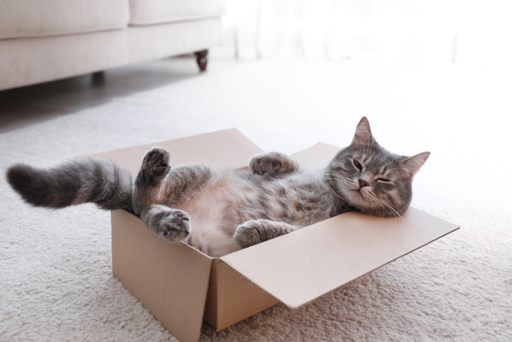

In [9]:
from PIL import Image
import requests
from io import BytesIO

# Download a sample image

image_url = "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/d5fbbd1a-d484-415c-88cb-9986625b7b11"
response = requests.get(image_url, timeout=30)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Resize for efficiency
image.thumbnail((512, 512))
display(image)

In [10]:
# Chat with single image (aligned with original model README)
question = "What is in the image?"
msgs = [{"role": "user", "content": [image, question]}]

answer = ov_model.chat(
    msgs=msgs,
    use_tts_template=False,
)
print(answer)

The image shows a relaxed, gray tabby cat lying on its back inside a small cardboard box. The cat appears to be sleeping or dozing peacefully, with its eyes partially closed and paws slightly curled. Its tail is stretched out behind it. The scene takes place indoors on a soft, light-colored carpet, with a blurred piece of furniture (possibly a sofa) visible in the background. The lighting is bright and natural, suggesting daylight coming from a nearby window.

This is a classic, endearing “cat in a box” moment — cats often enjoy boxes for their enclosed, secure feeling, even when they’re sprawled out and comfortable


### Multi-turn Conversation

The model supports multi-turn conversations with context awareness across turns.

In [11]:
# Multi-turn: follow up on the previous image
# Reset LLM state for fresh generation
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

msgs = [
    {"role": "user", "content": [image, "What is in this image?"]},
    {"role": "assistant", "content": [answer]},
    {"role": "user", "content": ["What season do you think this picture was taken in? Why?"]},
]

answer2 = ov_model.chat(
    msgs=msgs,
    use_tts_template=False,
    enable_thinking=False,
)
print(answer2)

This picture likely was taken during a warmer season, such as spring or summer. The bright natural lighting and the absence of heavy clothing or winter elements suggest mild indoor temperatures. Additionally, cats often sleep more comfortably in boxes indoors when it's warm outside, seeking cozy spots to relax.


## Speech and Audio Mode
[back to top ⬆️](#Table-of-contents:)

MiniCPM-o 4.5 can handle various audio understanding tasks. You can switch between different tasks by changing the prompt text:

| Task | Prompt |
|------|--------|
| **ASR (English)** | `Please listen to the audio snippet carefully and transcribe the content.` |
| **ASR (Chinese / AST EN→ZH)** | `请仔细听这段音频片段，并将其内容逐字记录。` |
| **Speaker Analysis** | `Based on the speaker's content, speculate on their gender, condition, age range, and health status.` |
| **General Audio Caption** | `Summarize the main content of the audio.` |
| **Sound Scene Tagging** | `Utilize one keyword to convey the audio's content or the associated scene.` |

### Audio Understanding (ASR)

In [12]:
import librosa
import numpy as np
import soundfile as sf
from IPython.display import display, Audio

audio_path = "assets/system_ref_audio.wav"

audio_input, _ = librosa.load(str(audio_path), sr=16000, mono=True)
print(f"✅ Audio loaded: {len(audio_input)/16000:.1f}s @ 16kHz")

# Display input audio
print("🎧 Input Audio:")
display(Audio(audio_input, rate=16000))

# Reset LLM state
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

# ASR task (aligned with original model README)
task_prompt = "Please listen to the audio snippet carefully and transcribe the content."
msgs = [{"role": "user", "content": [task_prompt, audio_input]}]

asr_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=512,
    use_tts_template=True,
    temperature=0.3,
)
print("ASR Result:", asr_result)

✅ Audio loaded: 16.8s @ 16kHz
🎧 Input Audio:


ASR Result: for a while we built a hyperloop test track adjacent to spacex just for a student competition to encourage innovative ideas in transport <unk> it actually ends up being the biggest vacuum chamber in the world after the large hadron collider


### More Audio Tasks

Let's try additional audio understanding capabilities: Speaker Analysis and Sound Scene Tagging.

In [13]:
# Speaker Analysis (aligned with original model README)
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

speaker_prompt = "Based on the speaker's content, speculate on their gender, condition, age range, and health status."
msgs = [{"role": "user", "content": [speaker_prompt, audio_input]}]

speaker_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=512,
    use_tts_template=True,
    temperature=0.3,
)
print("Speaker Analysis:", speaker_result)

# Sound Scene Tagging
ov_model.llm._ov_language.reset_state()
ov_model.llm._past_length = 0

scene_prompt = "Utilize one keyword to convey the audio's content or the associated scene."
msgs = [{"role": "user", "content": [scene_prompt, audio_input]}]

scene_result = ov_model.chat(
    msgs=msgs,
    do_sample=True,
    max_new_tokens=64,
    use_tts_template=True,
    temperature=0.3,
)
print("Sound Scene Tag:", scene_result)

Speaker Analysis: According to the content of this speaker, it seams that the gender of the speaker is male, and the speaker is in the state of sigh. What's more, I detect no distinct features related to the speaker's age. In addition, the speaker's health condition seems to be good.
Sound Scene Tag: Speech


## Half-Duplex Omni Mode
[back to top ⬆️](#Table-of-contents:)

The **Half-Duplex Omni Mode** combines vision, audio, and text inputs into a single inference. This is the primary mode for multimodal understanding tasks that involve both visual and auditory information (e.g., describing a video with sound).

We provide two inference modes aligned with the [original model documentation](https://huggingface.co/openbmb/MiniCPM-o-4_5):
- **Chat Inference** — single-pass generation with full response
- **Streaming Inference** — token-by-token generation for real-time display

**Note:** FFmpeg is required for video frame extraction (`get_video_frame_audio_segments` with `use_ffmpeg=True`) and video generation (`generate_duplex_video`). For more information, visit the [official FFmpeg website](https://www.ffmpeg.org/).
  **macOS (Homebrew):**
  ```bash
  brew install ffmpeg
  ```
  **Ubuntu/Debian:**
  ```bash
  sudo apt update && sudo apt install ffmpeg
  ```
  **Verify installation:**
  ```bash
  ffmpeg -version
  ```

### Chat Inference

In [ ]:
from minicpmo.utils import get_video_frame_audio_segments

ov_model = ov_model.as_duplex()

video_path = "assets/Skiing.mp4"

# Optional: Set reference audio for voice cloning
ref_audio_path = "assets/HT_ref_audio.wav"
sys_msg = ov_model.get_sys_prompt(ref_audio=ref_audio_path, mode="omni", language="en")

# Use stack_frames=5 for high refresh rate mode
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(video_path, stack_frames=1)
omni_contents = []
for i in range(len(video_frames)):
    omni_contents.append(video_frames[i])
    omni_contents.append(audio_segments[i])
    if stacked_frames is not None and stacked_frames[i] is not None:
        omni_contents.append(stacked_frames[i])

msg = {"role": "user", "content": omni_contents}
msgs = [sys_msg, msg]

# Note: Non-streaming audio generation (generate_audio=True in chat()) is not supported in
# the OpenVINO pipeline because it requires per-step hidden-state extraction from the LLM,
# which is not available with OV stateful models. For audio output, use the Streaming
# Inference cell below, which produces temporally coherent audio via KV-cache streaming.

res = ov_model.chat(
    msgs=msgs,
    max_new_tokens=4096,
    do_sample=True,
    temperature=0.7,
    use_tts_template=True,
    enable_thinking=False,
    omni_mode=True,  # Required for omni inference
    max_slice_nums=1,  # Increase for HD mode
)
print(res)

⌛ Loading OpenVINO Flow embeddings model from MiniCPM-o-4_5-OV/openvino_flow_embeddings_model.xml...
✅ Flow embeddings model loaded
⌛ Loading OpenVINO Flow estimator model from MiniCPM-o-4_5-OV/openvino_flow_estimator_chunk_model.xml...
✅ Flow estimator model loaded
⌛ Loading streaming flow encoder chunk model...
✅ Streaming flow encoder chunk model loaded
⌛ Loading OpenVINO HiFT model from MiniCPM-o-4_5-OV/openvino_hift_model.xml...
✅ HiFT model loaded on CPU
⌛ Loading s3tokenizer model...
✅ s3tokenizer model loaded
⌛ Loading campplus model (ONNX via OpenVINO)...
✅ campplus model loaded (ONNX)
The person in the picture is skiing down a snowy mountain slope. They are wearing an orange and black jacket, dark pants, and using ski poles for balance while navigating through fresh powder snow.


### Streaming Inference

MiniCPM-o 4.5 supports streaming text generation for real-time output. It returns a generator that yields text chunks token-by-token as they are produced, rather than waiting for the entire response.

This is aligned with the [**Streaming Inference** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#streaming-inference) in the original model README under Half-Duplex Omni Mode.

In [15]:
import librosa
import torch
from minicpmo.utils import get_video_frame_audio_segments

ov_model = ov_model.as_duplex()

# Fix the input shape for hift model for better performance
ov_model.init_tts(hift_input_len=100)

# Reset session for a new conversation (clears KV cache)
ov_model.reset_session()

# Optional: Load reference audio for voice cloning
ref_audio_path = "assets/HT_ref_audio.wav"
ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)
ov_model.init_token2wav_cache(ref_audio)

session_id = "demo"

# Extract video frames and audio segments (use stack_frames=5 for high refresh rate mode)
video_path = "assets/Skiing.mp4"
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(video_path, stack_frames=1)

# Build omni contents list
omni_contents = []
for i in range(len(video_frames)):
    omni_contents.append(video_frames[i])
    omni_contents.append(audio_segments[i])
    if stacked_frames is not None and stacked_frames[i] is not None:
        omni_contents.append(stacked_frames[i])

generate_audio = True
output_audio_path = "output.wav"

# Step 1: Prefill system prompt
sys_msg = ov_model.get_sys_prompt(ref_audio=ref_audio, mode="omni", language="en")
ov_model.streaming_prefill(session_id=session_id, msgs=[sys_msg])

# Step 2: Prefill omni chunks (is_last_chunk=True only for the last audio chunk)
audio_indices = [i for i, c in enumerate(omni_contents) if isinstance(c, np.ndarray)]
last_audio_idx = audio_indices[-1] if audio_indices else -1

for idx, content in enumerate(omni_contents):
    is_last_audio_chunk = idx == last_audio_idx
    msgs = [{"role": "user", "content": [content]}]
    ov_model.streaming_prefill(session_id=session_id, msgs=msgs, omni_mode=True, is_last_chunk=is_last_audio_chunk)

# Step 3: Generate response
iter_gen = ov_model.streaming_generate(
    session_id=session_id,
    generate_audio=generate_audio,
    use_tts_template=True,
    enable_thinking=False,
    do_sample=True,
)

audios = []
text = ""

if generate_audio:
    for wav_chunk, text_chunk in iter_gen:
        audios.append(wav_chunk)
        text += text_chunk

    generated_waveform = torch.cat(audios, dim=-1)[0]
    sf.write(output_audio_path, generated_waveform.cpu().numpy(), samplerate=24000)

    print("Text:", text)
    print("Audio saved to output.wav")
    display(Audio(generated_waveform.cpu().numpy(), rate=24000))
else:
    for text_chunk, is_finished in iter_gen:
        text += text_chunk
    print("Text:", text)

⌛ Loading OpenVINO Flow embeddings model from MiniCPM-o-4_5-OV/openvino_flow_embeddings_model.xml...
✅ Flow embeddings model loaded
⌛ Loading OpenVINO Flow estimator model from MiniCPM-o-4_5-OV/openvino_flow_estimator_chunk_model.xml...
✅ Flow estimator model loaded
⌛ Loading streaming flow encoder chunk model...
✅ Streaming flow encoder chunk model loaded
⌛ Loading OpenVINO HiFT model from MiniCPM-o-4_5-OV/openvino_hift_model.xml...
  📐 Reshaped HiFT to fixed: mel=[1,80,100], cache=[1,1,3840]
✅ HiFT model loaded on CPU
⌛ Loading s3tokenizer model...
✅ s3tokenizer model loaded
⌛ Loading campplus model (ONNX via OpenVINO)...
✅ campplus model loaded (ONNX)


/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://githu

fixed s3 encode
Text: The person in the picture is skiing down a snowy mountain slope.<|tts_eos|>
Audio saved to output.wav


## Half-Duplex Realtime Speech Conversation
[back to top ⬆️](#Table-of-contents:)

The **Half-Duplex Realtime Speech Conversation Mode** simulates real-time voice interaction by splitting the user's audio into 1-second chunks and processing them sequentially through the streaming pipeline. The model listens to all chunks, then generates a text (and optionally audio) response.

This is aligned with the [**Half-Duplex Realtime Speech Conversation Mode** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#half-duplex-realtime-speech-conversation-mode) in the original model README.

> **Note:** The `streaming_prefill()` and `streaming_generate()` APIs are available on both simplex and duplex objects. When called with `session_id` on a duplex object, they automatically dispatch to the simplex streaming implementation.

In [16]:
import librosa
import numpy as np
import torch
import soundfile as sf
from IPython.display import display, Audio

ov_model = ov_model.as_duplex()

# Set reference audio for voice style
ref_audio_path = "assets/system_ref_audio.wav"
ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)

# Example system msg for English Conversation
sys_msg = {
    "role": "system",
    "content": [
        "Clone the voice in the provided audio prompt.",
        ref_audio,
        "Please assist users while maintaining this voice style. Please answer the user's questions seriously and in a high quality. Please chat with the user in a highly human-like and oral style in English. You are a helpful assistant developed by ModelBest: MiniCPM-Omni",
    ],
}

# You can use each type of system prompt mentioned above in streaming speech conversation

# Reset state
ov_model.reset_session(reset_token2wav_cache=True)
ov_model.init_token2wav_cache(prompt_speech_16k=ref_audio)

session_id = "demo"

# First, prefill system turn
ov_model.streaming_prefill(
    session_id=session_id,
    msgs=[sys_msg],
    omni_mode=False,
    is_last_chunk=True,
)

# Here we simulate realtime speech conversation by splitting whole user input audio into chunks of 1s.
# Use the system reference audio as a demo input (replace with your own audio file)
user_audio, _ = librosa.load("assets/system_ref_audio.wav", sr=16000, mono=True)

IN_SAMPLE_RATE = 16000  # input audio sample rate, fixed value
CHUNK_SAMPLES = IN_SAMPLE_RATE  # sample
OUT_SAMPLE_RATE = 24000  # output audio sample rate, fixed value
MIN_AUDIO_SAMPLES = 16000

total_samples = len(user_audio)
num_chunks = (total_samples + CHUNK_SAMPLES - 1) // CHUNK_SAMPLES

for chunk_idx in range(num_chunks):
    start = chunk_idx * CHUNK_SAMPLES
    end = min((chunk_idx + 1) * CHUNK_SAMPLES, total_samples)
    chunk_audio = user_audio[start:end]

    is_last_chunk = chunk_idx == num_chunks - 1
    if is_last_chunk and len(chunk_audio) < MIN_AUDIO_SAMPLES:
        chunk_audio = np.concatenate([chunk_audio, np.zeros(MIN_AUDIO_SAMPLES - len(chunk_audio), dtype=chunk_audio.dtype)])

    user_msg = {"role": "user", "content": [chunk_audio]}

    # For each 1s audio chunk, perform streaming_prefill once to reduce first-token latency
    ov_model.streaming_prefill(
        session_id=session_id,
        msgs=[user_msg],
        omni_mode=False,
        is_last_chunk=is_last_chunk,
    )

# Let model generate response in a streaming manner
generate_audio = True
iter_gen = ov_model.streaming_generate(
    session_id=session_id,
    generate_audio=generate_audio,
    use_tts_template=True,
    enable_thinking=False,
    do_sample=True,
    max_new_tokens=512,
    length_penalty=1.1,  # For realtime speech conversation mode, we suggest length_penalty=1.1 to improve response content
)

audios = []
text = ""

output_audio_path = "output_realtime.wav"
if generate_audio:
    for wav_chunk, text_chunk in iter_gen:
        audios.append(wav_chunk)
        text += text_chunk

    generated_waveform = torch.cat(audios, dim=-1)[0]
    sf.write(output_audio_path, generated_waveform.cpu().numpy(), samplerate=24000)

    print("Text:", text)
    print(f"Audio saved to {output_audio_path}")
    display(Audio(generated_waveform.cpu().numpy(), rate=24000))
else:
    for text_chunk, is_finished in iter_gen:
        text += text_chunk
    print("Text:", text)

/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/home/ethan/intel/openvino_notebooks/py_env/lib/python3.10/site-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://githu

fixed s3 encode
Text: Uh, for a while we built a hyperloop test track adjacent to Space X just for a student competition. Um, to encourage innovative ideas in transport. Um, and actually ends up being the uh the biggest um vacuum chamber in the world after the launch heater and collider.<|tts_eos|>
Audio saved to output_realtime.wav


## Duplex Omni Mode
[back to top ⬆️](#Table-of-contents:)

The **Duplex Omni Mode** enables full-duplex streaming: the model can **listen and speak simultaneously**, processing multimodal input (video frames + audio chunks) in real time. This is the most advanced interaction mode, ideal for real-time conversations where the AI needs to respond while the user is still speaking.

This is aligned with the [**Duplex Omni Mode** section](https://huggingface.co/openbmb/MiniCPM-o-4_5#duplex-omni-mode) in the original model README.

The duplex pipeline works in a loop:
1. **`streaming_prefill()`** — Feed one audio chunk (+ optional video frames) to the model
2. **`streaming_generate()`** — Model decides to **listen** or **speak**, returning text + optional audio

In [ ]:
import librosa
import torch
from minicpmo.utils import generate_duplex_video, get_video_frame_audio_segments
from IPython.display import display, Video

# Ensure duplex mode for full duplex API
ov_model = ov_model.as_duplex() if hasattr(ov_model, "as_duplex") else ov_model

# Load video and reference audio
cn_video_path = "assets/omni_duplex1.mp4"
ref_audio_path = "assets/HT_ref_audio.wav"
en_video_url = "https://github.com/user-attachments/assets/f6ab8ed5-5829-4ce2-9feb-3a8bf7374dbb"
en_video_path = "assets/omni_duplex_en.mp4"

try:
    resp = requests.get(en_video_url, timeout=30)
    resp.raise_for_status()
    if not resp.content:
        raise ValueError("Downloaded file is empty.")
    with open(en_video_path, "wb") as f:
        f.write(resp.content)
    video_path = en_video_path
    print(f"✅ en_video downloaded: {cn_video_path}")
except Exception as e:
    video_path = cn_video_path
    print(f"⚠️ Download failed, fallback to {cn_video_path}\n{e}")

ref_audio, _ = librosa.load(ref_audio_path, sr=16000, mono=True)

ov_model.reset_session(reset_token2wav_cache=True)

# Extract video frames and audio segments
video_frames, audio_segments, stacked_frames = get_video_frame_audio_segments(video_path, stack_frames=1, use_ffmpeg=True, adjust_audio_length=True)

# Prepare duplex session with system prompt and voice reference
ov_model.prepare(
    prefix_system_prompt="Streaming Omni Conversation.",
    ref_audio=ref_audio,
    prompt_wav_path=ref_audio_path,
)

results_log = []
timed_output_audio = []

# Process each chunk in streaming fashion
for chunk_idx in range(len(audio_segments)):
    audio_chunk = audio_segments[chunk_idx] if chunk_idx < len(audio_segments) else None
    frame = video_frames[chunk_idx] if chunk_idx < len(video_frames) else None
    frame_list = []
    if frame is not None:
        frame_list.append(frame)
        if stacked_frames is not None and chunk_idx < len(stacked_frames) and stacked_frames[chunk_idx] is not None:
            frame_list.append(stacked_frames[chunk_idx])

    # Step 1: Streaming prefill
    ov_model.streaming_prefill(
        audio_waveform=audio_chunk,
        frame_list=frame_list,
        max_slice_nums=1,  # Increase for HD mode (e.g., [2, 1] for stacked frames)
        batch_vision_feed=False,  # Set True for faster processing
    )

    # Step 2: Streaming generate
    result = ov_model.streaming_generate(
        prompt_wav_path=ref_audio_path,
        max_new_speak_tokens_per_chunk=20,
        decode_mode="sampling",
    )

    if result["audio_waveform"] is not None:
        timed_output_audio.append((chunk_idx, result["audio_waveform"]))

    chunk_result = {
        "chunk_idx": chunk_idx,
        "is_listen": result["is_listen"],
        "text": result["text"],
        "end_of_turn": result["end_of_turn"],
        "current_time": result["current_time"],
        "audio_length": len(result["audio_waveform"]) if result["audio_waveform"] is not None else 0,
    }
    results_log.append(chunk_result)

    print("listen..." if result["is_listen"] else f"speak> {result['text']}")

# Generate output video with AI responses
# Please install Chinese fonts (fonts-noto-cjk or fonts-wqy-microhei) to render CJK subtitles correctly.
# apt-get install -y fonts-noto-cjk fonts-wqy-microhei
# fc-cache -fv
generate_duplex_video(
    video_path=video_path,
    output_video_path="duplex_output.mp4",
    results_log=results_log,
    timed_output_audio=timed_output_audio,
    output_sample_rate=24000,
)

# Play the generated video
display(Video("duplex_output.mp4", embed=True, width=640))

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Launch a Gradio-based multimodal chatbot with features inspired by the [official MiniCPM-V-CookBook demo](https://github.com/OpenSQZ/MiniCPM-V-CookBook):
- 💬 **Chat Tab** — text, image, and audio inputs with streaming output
- 🧠 **Thinking Mode** — toggle to see the model's reasoning process
- 📚 **Few-Shot Tab** — add example pairs, then generate with pattern matching
- ⏹ **Stop Button** — interrupt generation at any time
- 🎛️ **Sampling Controls** — temperature, top-p, top-k, repetition penalty

In [ ]:
from gradio_helper import make_demo

if hasattr(ov_model, "as_simplex"):
    ov_model = ov_model.as_simplex()

demo = make_demo(ov_model)
try:
    demo.launch(debug=False, height=800)
except Exception:
    demo.launch(debug=False, share=True, height=800)